<a href="https://colab.research.google.com/github/Deangr-econ/Quant_methods_project/blob/main/VAR_GPRD_OIL_GAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install fredapi

In [9]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, kpss
import statsmodels.api as sm
import scipy.stats as stats
from fredapi import Fred
from google.colab import userdata
import sys
from google.colab import drive
fred = Fred(api_key=userdata.get('fredapi_key'))

In [10]:
# 1. Drive sicherstellen
drive.mount("/content/drive")

# 2. Ordnerpfad hinzufügen
folder_path = "/content/drive/MyDrive/Colab Notebooks"
if folder_path not in sys.path:
  sys.path.insert(0, folder_path)

# 3. Den genauen Dateinamen der .py-Datei verwenden (alles Kleinbuchstaben)
import group_project_qtfe_functions as gf

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
start_date = "1990-01-01"
end_date = "2026-09-01"

raw_prices = yf.download(["^GSPC", "CL=F"], start=start_date, end=end_date)

df_vol = pd.DataFrame(index=raw_prices.index)
df_vol["SP500_GK_SD"] = gf.garman_klass_sd(raw_prices, "^GSPC")
df_vol["Oil_GK_SD"] = gf.garman_klass_sd(raw_prices, "CL=F")
df_vol.index = pd.to_datetime(df_vol.index).tz_localize(None).normalize()

# 4. Pull 10Y-2Y Treasury Yield Spread from FRED
# T10Y2Y represents 10Y minus 2Y constant maturity yield spread (in percentage points)
fred_spread = fred.get_series('T10Y2Y', observation_start=start_date)
fred_spread.index = pd.to_datetime(fred_spread.index).normalize()

fred_spread_diff = fred_spread.diff()
fred_spread_diff.name = "T10Y2Y_DIFF"

df_vol = df_vol.join(fred_spread_diff)

# 5. Clean Alignment
master_vol = df_vol.dropna()

/tmp/ipykernel_43951/402299206.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_prices = yf.download(["^GSPC", "CL=F"], start=start_date, end=end_date)
[*********************100%***********************]  2 of 2 completed
/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [18]:
# gspc = yf.download(tickers='^GSPC', start='1990-01-01', auto_adjust=True)
# fred = Fred(api_key=userdata.get('fredapi_key'))
# oil_vol = fred.get_series('DCOILBRENTEU', observation_start='1985-01-01')
# treasury_2y = fred.get_series('DGS2', observation_start='1985-01-01')
# treasury_5y = fred.get_series('DGS5', observation_start='1985-01-01')
# treasury_10y = fred.get_series('DGS10', observation_start='1985-01-01')


# api_data = pd.DataFrame({
#     'sp500': gspc,
#     'oil': oil_data,
#     'i2': treasury_2y,
#     'i5': treasury_5y,
#     'i10': treasury_10y,
#     })

# api_data['i2'] = pd.to_numeric(api_data['i2'], errors='coerce')
# api_data['i5'] = pd.to_numeric(api_data['i5'], errors='coerce')
# api_data['i10'] = pd.to_numeric(api_data['i10'], errors='coerce')

In [29]:
#2. Data transformation


# # Download Energy Futures
# api_data = yf.download(
#     tickers=['CL=F', 'NG=F'],
#     start='1990-01-01',
#     auto_adjust=True
# )['Close']

# gpr.index = pd.to_datetime(gpr.index).tz_localize(None)
# merged = api_data.join(gpr['GPRD'], how='inner')

api_data = df_vol.copy()

# Strip timezone if present
api_data.index = pd.to_datetime(api_data.index).tz_localize(None)

# 2. Find the first timestamp where ALL columns have non-null values
first_valid = api_data.dropna().index.min()
# 3. Slice from that date onward
data = api_data.loc[first_valid:].dropna()

In [22]:
# 4. Clean non-positive crude anomaly (2020-04-20)
# data['oil'] = data['oil'].mask(data['oil'] <= 0).ffill()

# 5. Build explicit stationary DataFrame for VAR estimation
# var_df = pd.DataFrame(index=data.index)

# var_df['sp500'] = np.log(data['sp500']).diff() # 1. Asset Prices -> Log returns
# var_df['oil_RET'] = np.log(data['oil']).diff() # 1. Asset Prices -> Log returns

# var_df['GAS_RET'] = np.log(data['GAS_PRICE']).diff()
# var_df['D_CRUDE_VOL'] = data['CRUDE_VOLATILITY'].diff() # 2. Volatility -> First differences (keeps linear scale intact)

# var_df['i2'] = data['i2'].diff() # 3. Rates & Percentages -> First differences (avoids log of zero/negative numbers)

# var_df['i5'] = data['i5'].diff()
# var_df['i10'] = data['i10'].diff()

# var_df['LOG_GPR'] = np.log(data['GPRD'].clip(lower=1e-5)) # 4. Geopolitical Risk Index -> Log level (stationary; measures proportional shock intensity)

# Drop initial NaN created by differencing
# var_df = var_df.dropna()

In [30]:
# 3. Testing for Unit Root / Stationarity

stationarity_results = gf.test_stationarity_table(data)
stationarity_results

/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_res = kpss(


,ADF Stat,ADF p-value,KPSS Stat,KPSS p-value,Conclusion (α=0.05)
Variable,,,,,
SP500_GK_SD,-7.3040,1.3160e-10,0.8555,0.010,Contradictory / Structural Break
Oil_GK_SD,-7.1074,4.0195e-10,0.3586,0.095,Stationary
T10Y2Y_DIFF,-13.4959,3.0421e-25,0.2153,0.100,Stationary


<Axes: xlabel='Date'>

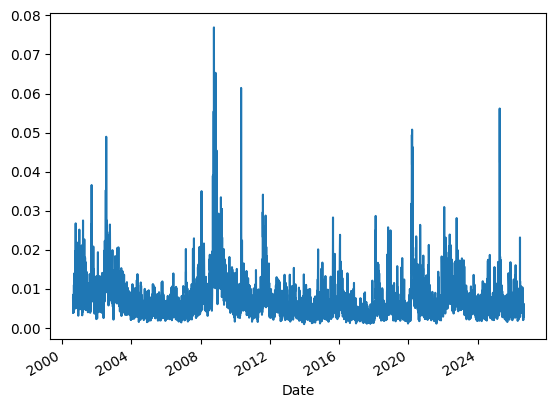

In [33]:
data['SP500_GK_SD'].plot()

In [34]:
#4. Model Selection

#  Clip extreme outliers in EXP_INFLATION to +/- 4 standard deviations
# There were extreme 47 std outliers in the expected inflation data

# lower_bound = data['D_EXP_INFLATION'].quantile(0.001)
# upper_bound = data['D_EXP_INFLATION'].quantile(0.999)

# data_clean = data.copy()
# data_clean['D_EXP_INFLATION'] = data_clean['D_EXP_INFLATION'].clip(lower=lower_bound, upper=upper_bound)

# Refit standard model
model = VAR(data)

# model = VAR(endog=data)
# Evaluate lags 1 through 15
lag_order = model.select_order(maxlags=20)
print(lag_order.summary())

# Choose lag by AIC (more flexible) or BIC (more parsimonious)
optimal_lag = lag_order.aic
print(f"Optimal lag according to aic: {optimal_lag}")

# Fit the VAR model with the selected lag
results = model.fit(optimal_lag)
total_coefs = results.params.size
print(f"Total regression coefficients: {total_coefs}")

print(results.summary())



# # Does GPR predict Oil returns?
# gc_oil = results.test_causality('OIL', ['GPRD'], kind='f')
# print("Granger Causality (GPR -> Oil):")
# print(gc_oil.summary())

# # Does GPR predict Gas returns?
# gc_gas = results.test_causality('GAS', ['GPRD'], kind='f')
# print("\nGranger Causality (GPR -> Gas):")
# print(gc_gas.summary())




/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -25.59      -25.58   7.717e-12      -25.59
1       -26.74      -26.72   2.447e-12      -26.73
2       -26.91      -26.88   2.062e-12      -26.90
3       -26.98      -26.94   1.924e-12      -26.97
4       -27.02      -26.98   1.845e-12      -27.00
5       -27.04     -26.99*   1.803e-12      -27.02
6       -27.04      -26.98   1.798e-12      -27.02
7       -27.05      -26.98   1.786e-12      -27.03
8       -27.06      -26.98   1.775e-12      -27.03
9       -27.07      -26.98   1.758e-12      -27.03
10      -27.08      -26.97   1.743e-12     -27.04*
11      -27.07      -26.96   1.744e-12      -27.04
12      -27.08      -26.96   1.741e-12      -27.03
13      -27.08      -26.95   1.735e-12      -27.03
14      -27.08      -26.94   1.732e-12      -27.03
15      -27.08      -26.93   1.727e-12      -27.03
16      -27.08      -26.92   1.

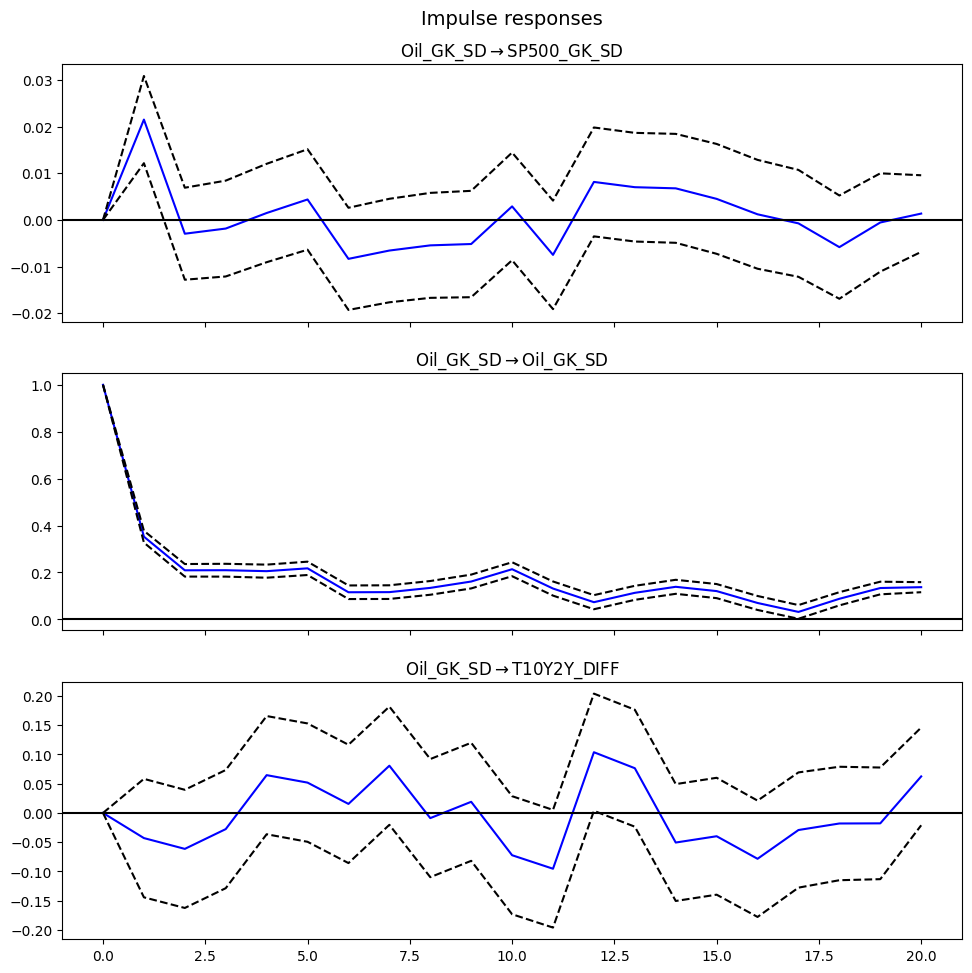

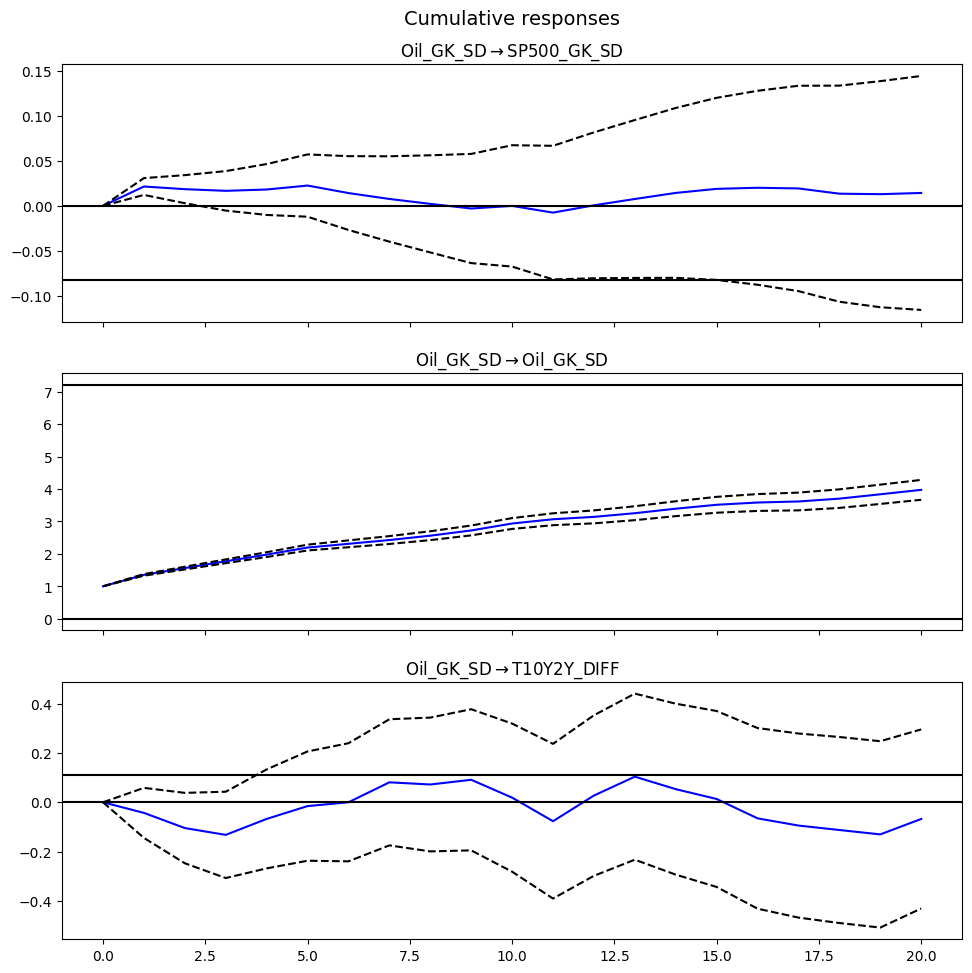

In [35]:
# Compute orthogonalized IRFs (default uses Cholesky ordering based on DataFrame column order)
irf = results.irf(periods=20)

# Plot responses to a GPR shock
fig = irf.plot(impulse='Oil_GK_SD')
plt.show()

# Cumulative IRF (to see net directional impact over time)
fig_cum = irf.plot_cum_effects(impulse='Oil_GK_SD')
plt.show()

In [ ]:
# periods = 10
# girf_results = compute_girf_matrix(results, periods=periods)

# # 2. Inspect a specific shock-response trajectory
# # Example: Impact of a 1-SD shock to 'LOG_GPR' on 'OIL_PRICE' over 10 days
# shock_var = "i2"
# target_var = "oil_RET"

# response_path = girf_results[shock_var][target_var]
# print(f"GIRF Response of {target_var} to {shock_var} shock:")
# print(np.round(response_path, 4))

GIRF Response of oil_RET to i2 shock:
[ 0.0023  0.0003  0.0009 -0.0002  0.0002  0.0005 -0.      0.0004 -0.0002
 -0.      0.0001]


In [36]:
fevd = results.fevd(10)
print(fevd.summary())
# fevd.plot()
# plt.show()

FEVD for SP500_GK_SD
     SP500_GK_SD  Oil_GK_SD  T10Y2Y_DIFF
0       1.000000   0.000000     0.000000
1       0.997045   0.002955     0.000000
2       0.997223   0.002753     0.000024
3       0.996753   0.002624     0.000623
4       0.996862   0.002531     0.000607
5       0.996829   0.002537     0.000635
6       0.996461   0.002806     0.000733
7       0.995917   0.002918     0.001165
8       0.995727   0.002976     0.001296
9       0.995177   0.003029     0.001794

FEVD for Oil_GK_SD
     SP500_GK_SD  Oil_GK_SD  T10Y2Y_DIFF
0       0.016714   0.983286     0.000000
1       0.022932   0.976696     0.000373
2       0.036068   0.963513     0.000419
3       0.040552   0.959034     0.000414
4       0.044743   0.954813     0.000444
5       0.048790   0.950771     0.000439
6       0.054658   0.944871     0.000471
7       0.058549   0.940982     0.000469
8       0.060049   0.939370     0.000581
9       0.060434   0.938860     0.000706

FEVD for T10Y2Y_DIFF
     SP500_GK_SD  Oil_GK_SD  T10Y2Y

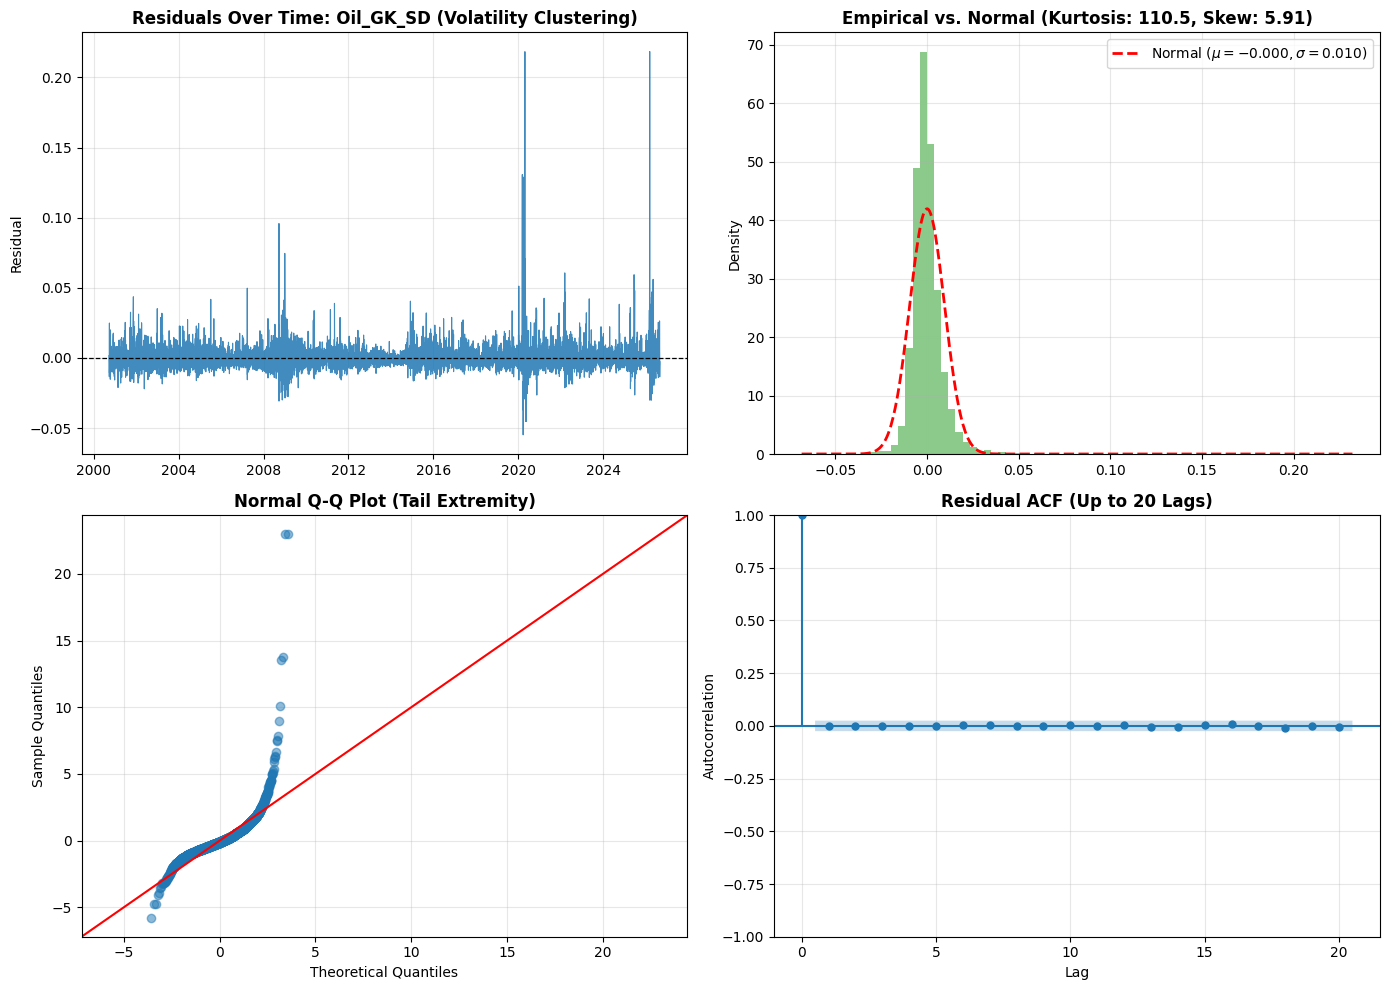

In [37]:
gf.plot_var_residual_diagnostics(results, 'Oil_GK_SD')

In [ ]:
# Find the exact date of the worst drop
worst_date = var_df['GAS_RET'].idxmin()
print("Worst outlier date:", worst_date)
print("Outlier value:", var_df.loc[worst_date, 'GAS_RET'])

# Check the top 5 most extreme absolute swings
print("\nTop 5 absolute swings in GAS_RET:")
print(var_df['GAS_RET'].abs().nlargest(5))

Worst outlier date: 2024-01-16 00:00:00
Outlier value: -1.401561833250679

Top 5 absolute swings in GAS_RET:
2024-01-12    1.432814
2024-01-16    1.401562
2026-01-23    1.294304
2021-02-18    1.025103
2025-01-17    0.829871
Name: GAS_RET, dtype: float64
